# Macro Models

In [33]:
# generate background distribution
from benchmark import MexicanHat, OrnsteinUhlenbeck, SoftLaplace, StudentT

n_dim = 5
diffusion = 0.5

# background process
PGenerator = MexicanHat(n_dim=n_dim, shape_factor_intensity=0.1, temperature=1.0, batch_size=1000, radius=1.0)
PcGenerator = MexicanHat(n_dim=n_dim, shape_factor_intensity=0.1, temperature=1.0/diffusion, batch_size=10000, radius=1.0)
QGenerator = OrnsteinUhlenbeck(n_dim=n_dim, temperature=1.0, shape_factor_intensity=0.0)
#QGenerator = StudentT(n_dim=n_dim, tail_weight=n_dim/2+2.0, shape_factor_intensity=0.0, beta=20.0)

assert QGenerator.is_normalized(), "QGenerator is not normalized"

In [34]:
# plot histogram of QGenerator
"""
from matplotlib import pyplot as plt
import torch
plt.figure(figsize=(8, 6))
#plt.hist(PGenerator(100000).cpu().numpy(), bins=100, density=True, range=(-10, 10), alpha=0.5, label='QGenerator')
x_grid = torch.linspace(-10, 10, 1000).unsqueeze(1)
plt.plot(x_grid.cpu().numpy(), PGenerator.log_prob(x_grid).exp().cpu().numpy() / Z, label='QGenerator PDF', color='red')
plt.plot(x_grid.cpu().numpy(), QGenerator.log_prob(x_grid).exp().cpu().numpy(), label='QGenerator PDF', color='red')
plt.plot(x_grid.cpu().numpy(), PcGenerator.log_prob(x_grid).exp().cpu().numpy() / Zc, label='PcGenerator PDF', color='red')
plt.show()
"""
pass

Training:   0%|          | 0/100 [00:00<?, ?it/s]

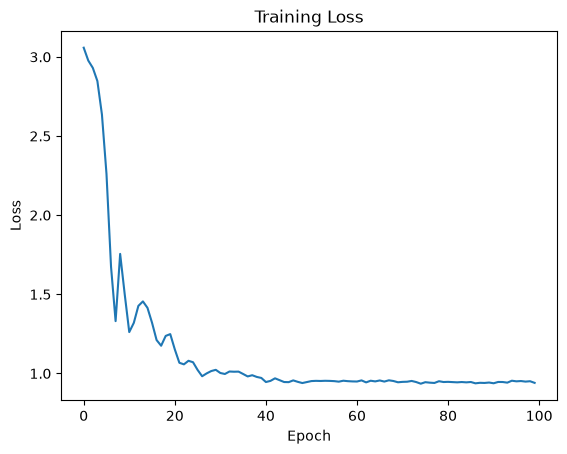

Final loss: 0.9287362098693848


In [35]:
# Definition of the neural network
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW, Adam
from math import log2
from tqdm.notebook import tqdm

class SimpleNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, n_layers: int):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            *[nn.Sequential(
                nn.Dropout(0.1), 
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU()) for _ in range(n_layers - 1)],
            nn.Linear(hidden_dim, 1)
        )
        # creo il peso b
        self.b = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        M = self.net(x)
        p_est = M
        pc_est = M*diffusion-self.b
        q_est = QGenerator.log_prob(x).unsqueeze(1)
        logits = torch.cat((p_est, pc_est, q_est), dim=1)
        return logits

myNet = SimpleNN(input_dim=n_dim, hidden_dim=512, n_layers=5)
myNet.train()

optimizer = AdamW(myNet.net.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

n_epochs = 100
batch_size = int(256*(2*n_dim*log2(n_dim)+2))
loss_history = []
for epoch in tqdm(range(n_epochs), desc="Training"):
    # genero i batch
    Psamples  = PGenerator (n_samples=batch_size)
    Pcsamples = PcGenerator(n_samples=batch_size)
    Qsamples  = QGenerator (n_samples=batch_size)
    Plabels  = torch.full((batch_size,), 0, dtype=torch.long)
    Pclabels = torch.full((batch_size,), 1, dtype=torch.long)
    Qlabels  = torch.full((batch_size,), 2, dtype=torch.long)
    # merge Psamples e Qsamples
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels  = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    # outputs has shape (N,3)
    # batch_labels has shape (N,)
    loss = criterion(outputs, batch_labels)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    # newton per il parametro b
    myNet.eval()  # è importante spegnere il training mode per evitare che il dropout influisca sul calcolo del gradiente e dell'hessiano
    with torch.no_grad():
        for i in range(1):
            # calcolo il gradiente e l'hessiano rispetto a b
            logits = myNet(batch_samples)
            probs = torch.softmax(logits, dim=1)
            C1 = probs[:, 1]
            f_prime = 1.0/3.0 - torch.mean(C1)
            f_second = torch.mean(C1 * (1.0 - C1))
            # aggiorno b con un passo di newton
            myNet.b -= f_prime / (f_second + 1e-8)  # anche se il problema è convesso, ha code lineari. Richiede regolarizzazione.
    myNet.train()

from matplotlib import pyplot as plt
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

myNet.eval()
with torch.no_grad():
    Psamples = PGenerator(n_samples=10000)
    Pcsamples = PcGenerator(n_samples=10000)
    Qsamples = QGenerator(n_samples=10000)
    Plabels = torch.full((10000,), 0, dtype=torch.long)
    Pclabels = torch.full((10000,), 1, dtype=torch.long)
    Qlabels  = torch.full((10000,), 2, dtype=torch.long)
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    loss = criterion(outputs, batch_labels)
    print(f"Final loss: {loss.item()}")

In [36]:
# show outputs of the neural network along the axis in 1D
"""
from matplotlib import pyplot as plt

X = torch.linspace(-10, 10, 1000).unsqueeze(1)
with torch.no_grad():
    outputs = torch.softmax(myNet(X), dim=1)
    plt.plot(X.numpy(), outputs.numpy())
    plt.title("Neural Network Outputs")
    plt.xlabel("Input")
    plt.ylabel("Output Probabilities")
    plt.legend(["P", "Pc", "Q"])
    plt.show()
    
# best optimizer: theoretical solution
def best_C(samples):
    p_est = PGenerator.log_prob(samples) - torch.log(Z)
    pc_est = PcGenerator.log_prob(samples) - torch.log(Zc)
    q_est = QGenerator.log_prob(samples)
    C = torch.cat((p_est.unsqueeze(1), pc_est.unsqueeze(1), q_est.unsqueeze(1)), dim=1)
    return C

with torch.no_grad():
    outputs = best_C(X).softmax(dim=1)
    plt.plot(X.numpy(), outputs.numpy())
    plt.title("Optimal Model Outputs")
    plt.xlabel("Input")
    plt.ylabel("Output Probabilities")
    plt.legend(["P", "Pc", "Q"])
    plt.show()

pass

gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
Z = utils.compute_normalization_constant(PGenerator, samples_integration, bg_log_probs)
print(f"Normalization constant of objective density: {Z}")

gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
Zc = utils.compute_normalization_constant(PcGenerator, samples_integration, bg_log_probs)
print(f"Normalization constant of objective density: {Zc}")

def best_C(samples):
    p_est = PGenerator.log_prob(samples) - torch.log(Z)
    pc_est = PcGenerator.log_prob(samples) - torch.log(Zc)
    q_est = QGenerator.log_prob(samples)
    C = torch.cat((p_est.unsqueeze(1), pc_est.unsqueeze(1), q_est.unsqueeze(1)), dim=1)
    return C

myNet.eval()
with torch.no_grad():
    Psamples = PGenerator(n_samples=10000)
    Pcsamples = PcGenerator(n_samples=10000)
    Qsamples = QGenerator(n_samples=10000)
    Plabels = torch.full((10000,), 0, dtype=torch.long)
    Pclabels = torch.full((10000,), 1, dtype=torch.long)
    Qlabels  = torch.full((10000,), 2, dtype=torch.long)
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    best_outputs = best_C(batch_samples)
    loss = criterion(outputs, batch_labels)
    best_loss = criterion(best_outputs, batch_labels)
    print(f"Final loss: {loss.item()}")
    print(f"Best loss: {best_loss.item()}")
"""
pass

In [37]:
# get the density p from the trained network
from benchmark import utils

def p_estimated(myNet, samples):
    M = myNet.net(samples).squeeze(1)
    return torch.exp(M)

def p_estimated_from_C(classifier, samples):
    C = classifier(samples).squeeze(1)
    prob_Q = QGenerator.log_prob(samples).exp()
    value1 = C[:,1]**2 / C[:,0]
    value2 = 1 - C[:,2]
    value3 = torch.sqrt(value1 + 4*value2) - torch.sqrt(value1)
    return (value3 ** 2 / (4 * C[:,2])) * prob_Q

# 0. Mass invariant:
gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
# remove couples of samples with bg_log_probs.exp() < 1e-10 to avoid numerical issues
mask = bg_log_probs.exp() >= 1e-10
samples_integration = samples_integration[mask]
bg_log_probs = bg_log_probs[mask]
empirical_mass = torch.mean(p_estimated(myNet, samples_integration) / bg_log_probs.exp()).item()
print(f"Empirical mass: {empirical_mass}")

def p_corrected(myNet, samples):
    return p_estimated(myNet, samples)

gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
Z = utils.compute_normalization_constant(PGenerator, samples_integration, bg_log_probs)
print(f"Normalization constant of objective density: {Z}")

def p_true(Pgenerator, samples):
    if Pgenerator.is_normalized:
        return Pgenerator.log_prob(samples).exp()
    else:
        return Pgenerator.log_prob(samples).exp() / Z

Empirical mass: 1.0190187692642212
Normalization constant of objective density: 52.96672821044922


In [38]:
# plot
"""
X = torch.linspace(-5, 5, 1000).unsqueeze(1)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(X.numpy(), p_corrected(myNet, X).detach().cpu().numpy(), label='Estimated density p(x)', color='blue')
plt.plot(X.numpy(), p_true(PGenerator, X).detach().cpu().numpy(), label='True density p(x)', color='red', linestyle='dashed')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Density Estimation')
plt.legend()
plt.show()
"""
pass

In [39]:
# calcolo dell'errore

if 'emp_mass' not in locals():
    emp_mass = []
if 'l1_norm' not in locals():
    l1_norm = []
if 'l2_norm' not in locals():
    l2_norm = []
if 'linf_norm' not in locals():
    linf_norm = []
if 'kl' not in locals():
    kl = []
if 'js_div' not in locals():
    js_div = []
if 'fisher_divergence' not in locals():
    fisher_divergence = []

# 0. empirical mass invariant: E[p_corrected / p_true] = 1
emp_mass.append(empirical_mass)

# 1. KL(p_true | p_corrected) = E[log(p_true / p_corrected)] = E[log(p_true)] - E[log(p_corrected)]
def KL_divergence(PGenerator, QGenerator_log_prob):
    Psamples = PGenerator(n_samples=100000)
    Z = utils.compute_normalization_constant(PGenerator, Psamples, PGenerator.log_prob(Psamples))
    entropy = torch.mean(PGenerator.log_prob(Psamples)) - torch.log(torch.tensor(Z))
    KL_divergence = entropy - torch.mean(QGenerator_log_prob(Psamples))
    return KL_divergence
log_p_corrected = lambda x: torch.log(p_corrected(myNet, x) + 1e-12) # 1e-12 per evitare log(0)
kl.append(KL_divergence(PGenerator, log_p_corrected).item())

# 2. JS(p_true | p_corrected) = 0.5 * KL(p_true | m) + 0.5 * KL(p_corrected | m), where m = 0.5 * (p_true + p_corrected)
m_log_prob = lambda x: torch.log(0.5 * (p_true(PGenerator, x) + p_corrected(myNet, x)))
kl1 = KL_divergence(PGenerator, m_log_prob)
Qsamples = QGenerator(n_samples=100000)
q_densities = QGenerator.log_prob(Qsamples).exp()
p_theta_densities = p_corrected(myNet, Qsamples)
m_densities = 0.5 * (p_true(PGenerator, Qsamples) + p_theta_densities)
# filtro i dati con m_densities < 1e-10 per evitare log(0)
p_theta_densities = p_theta_densities[m_densities >= 1e-10]
q_densities = q_densities[m_densities >= 1e-10]
m_densities = m_densities[m_densities >= 1e-10]
kl2 = torch.mean(p_theta_densities / q_densities * torch.log(p_theta_densities / m_densities))
js_div.append(0.5 * kl1.item() + 0.5 * kl2.item())

# 3. L1, L2, L_infty norms of the difference between p_true and p_corrected
Qsamples = QGenerator(n_samples=100000)
densities = QGenerator.log_prob(Qsamples).exp()
err = p_true(PGenerator, Qsamples) - p_corrected(myNet, Qsamples)
l1_norm.append(torch.mean(torch.abs(err) / densities).item())
l2_norm.append(torch.sqrt(torch.mean(err**2 / densities)).item())
linf_norm.append(torch.max(torch.abs(err)).item())

# 4. Fisher Divergence: E[||grad(log(p_true)) - grad(log(p_corrected))||^2]
Psamples = PGenerator(n_samples=100000)
Psamples.requires_grad_(True) # Abilitiamo i gradienti per l'input!
Pscore = PGenerator.score(Psamples)
# Estraiamo l'output M della rete (log-prob non normalizzata)
# Visto che p(x) \propto exp(M(x)), lo score è semplicemente grad(M(x))
M_out = myNet.net(Psamples) 
# Calcoliamo la derivata spaziale esatta tramite autograd
Net_score = torch.autograd.grad(
    outputs=M_out, 
    inputs=Psamples, 
    grad_outputs=torch.ones_like(M_out), 
    create_graph=False
)[0]
fisher_div = torch.mean(torch.sum((Pscore - Net_score)**2, dim=-1))
fisher_divergence.append(fisher_div.item())

C:\Users\Stefano\AppData\Local\Temp\ipykernel_17756\2158997321.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  entropy = torch.mean(PGenerator.log_prob(Psamples)) - torch.log(torch.tensor(Z))


In [40]:
import numpy as np
def generate_latex_table(dim, results):
    tex = "\\begin{center}\n\\begin{tabular}{ c || c c c c c | c }\n"
    tex += f" {dim}D & Test1 & Test2 & Test3 & Test4 & Test5 & Average \\\\\n"
    tex += " \\hline\n \\hline\n"
    
    # Chiavi formattate pronte per stare dentro i dollari di LaTeX
    sections = {
        'Mass': ['\\text{Mass}'],
        'Spatial': ['L_1', 'L_2', 'L_\\infty'],
        'Divergences': ['\\text{KL Div}', '\\text{JS Div}'],
        'Fisher': ['\\text{Fisher Div}']
    }
    
    for sec_name, keys in sections.items():
        for k in keys:
            # Estraiamo la chiave "pulita" se nel dizionario 'results' non hai usato \text{}
            raw_key = k.replace('\\text{', '').replace('}', '')
            
            if raw_key in results:
                vals = results[raw_key]
                avg = np.mean(vals)
                row_str = " & ".join([f"${v:.3f}$" for v in vals])
                # Ora la metrica è tra i dollari!
                tex += f" ${k}$ & {row_str} & ${avg:.3f}$ \\\\\n"
        tex += " \\hline\n"
        
    tex = tex.rstrip(" \\hline\n") + "\n\\end{tabular}\n\\end{center}"
    
    print(tex)
    
generate_latex_table(n_dim, {
    'Mass': emp_mass,
    'L_1': l1_norm,
    'L_2': l2_norm,
    'L_\\infty': linf_norm,
    'KL Div': kl,
    'JS Div': js_div,
    'Fisher Div': fisher_divergence
})

\begin{center}
\begin{tabular}{ c || c c c c c | c }
 5D & Test1 & Test2 & Test3 & Test4 & Test5 & Average \\
 \hline
 \hline
 $\text{Mass}$ & $0.999$ & $0.980$ & $1.024$ & $0.985$ & $1.019$ & $1.001$ \\
 \hline
 $L_1$ & $0.313$ & $0.374$ & $0.297$ & $0.363$ & $0.323$ & $0.334$ \\
 $L_2$ & $0.031$ & $0.037$ & $0.027$ & $0.040$ & $0.029$ & $0.033$ \\
 $L_\infty$ & $0.029$ & $0.031$ & $0.023$ & $0.037$ & $0.024$ & $0.029$ \\
 \hline
 $\text{KL Div}$ & $4.072$ & $3.890$ & $4.085$ & $3.729$ & $4.073$ & $3.970$ \\
 $\text{JS Div}$ & $1.998$ & $1.888$ & $2.022$ & $1.799$ & $2.014$ & $1.944$ \\
 \hline
 $\text{Fisher Div}$ & $22.073$ & $24.788$ & $22.633$ & $25.593$ & $21.936$ & $23.405$
\end{tabular}
\end{center}
